# 00 — Label Mapping y Unificación de Datasets

Exploración de cada fuente en su **formato nativo**, mapeo a la estructura canónica (11 clases, estilo CheXpert) y verificación con un `DataLoader` independiente por fuente.

| Dataset | Formato CSV nativo | Labels mapeados | Imágenes |
|---|---|---|---|
| **ChestXray8** (NIH) | `"Cardiomegaly|Effusion"` (pipe-separated) | 12 findings → 11 canónicos | 112 120 `.png` |
| **CheXpert** (Stanford) | Columna por label; `−1` = incierto, `NaN` = no observado | 8 mapeados + 3 NaN estructural | 223 414 `.jpg` |
| **VinBigData** (Kaggle) | Una fila por hallazgo por radiólogo + bbox | 9 mapeados + 2 NaN estructural | 15 000 `.jpg` |

In [66]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DATASET_ROOT = os.path.abspath(os.path.join(".."))

CANONICAL_LABELS = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema",
    "Pleural_Effusion", "Pneumonia", "Pneumothorax",
    "Infiltration", "Nodule_Mass", "Pleural_Thickening", "No_Finding",
]
NUM_CLASSES = len(CANONICAL_LABELS)

_BASE_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

print(f"Dataset root: {DATASET_ROOT}")
print(f"{NUM_CLASSES} clases canónicas: {CANONICAL_LABELS}")

Dataset root: e:\dataset
11 clases canónicas: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural_Effusion', 'Pneumonia', 'Pneumothorax', 'Infiltration', 'Nodule_Mass', 'Pleural_Thickening', 'No_Finding']


---
## 1. ChestXray8 (NIH)

### 1.1 Estructura del dataset

```
ChestXray8/
├── Data_Entry_2017.csv   ← metadata + labels (112 120 filas)
├── BBox_List_2017.csv    ← bounding boxes opcionales
├── train_val_list.txt    ← IDs de imágenes para train+val
├── test_list.txt         ← IDs de imágenes para test
└── images_001/ … images_012/
    └── images/
        └── *.png         ← radiografías (distribuidas en 12 carpetas)
```

### 1.2 Formato de labels

Los labels son un string pipe-separated en la columna `Finding Labels`:
- `"No Finding"` — sin patología
- `"Cardiomegaly|Effusion"` — multi-label
- Posibles valores: 14 findings distintos

In [67]:
cx8_csv = pd.read_csv(
    os.path.join(DATASET_ROOT, "ChestXray8", "Data_Entry_2017.csv"),
    low_memory=False,
)
print(f"Filas: {len(cx8_csv):,}  |  Columnas: {cx8_csv.columns.tolist()}")
print()
print(cx8_csv[["Image Index", "Finding Labels", "Patient ID", "View Position"]].head(8).to_string(index=False))
print()
print("Top 15 Finding Labels:")
print(cx8_csv["Finding Labels"].value_counts().head(15).to_string())

Filas: 112,120  |  Columnas: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']

     Image Index         Finding Labels  Patient ID View Position
00000001_000.png           Cardiomegaly           1            PA
00000001_001.png Cardiomegaly|Emphysema           1            PA
00000001_002.png  Cardiomegaly|Effusion           1            PA
00000002_000.png             No Finding           2            PA
00000003_000.png                 Hernia           3            PA
00000003_001.png                 Hernia           3            PA
00000003_002.png                 Hernia           3            PA
00000003_003.png    Hernia|Infiltration           3            PA

Top 15 Finding Labels:
Finding Labels
No Finding                  60361
Infiltration                 9547
Atelectasis                  4215
Effusion                     3955
No

### 1.3 Mapeo a labels canónicos

| ChestXray8 raw | → | Canónico |
|---|---|---|
| Atelectasis | → | Atelectasis |
| Cardiomegaly | → | Cardiomegaly |
| Consolidation | → | Consolidation |
| Edema | → | Edema |
| **Effusion** | → | Pleural_Effusion |
| Infiltration | → | Infiltration |
| **Mass**, **Nodule** | → | Nodule_Mass (OR lógico) |
| Pleural_Thickening | → | Pleural_Thickening |
| Pneumonia | → | Pneumonia |
| Pneumothorax | → | Pneumothorax |
| **No Finding** | → | No_Finding |
| Emphysema, Fibrosis, Hernia | → | *(no mapeados)* |

Los 11 canónicos se inicializan en `0.0`; cada finding raw que aparece en el string activa su canónico a `1.0`.

In [ ]:
CX8_TO_CANONICAL = {
    "Atelectasis":        "Atelectasis",
    "Cardiomegaly":       "Cardiomegaly",
    "Consolidation":      "Consolidation",
    "Edema":              "Edema",
    "Effusion":           "Pleural_Effusion",
    "Infiltration":       "Infiltration",
    "Mass":               "Nodule_Mass",
    "Nodule":             "Nodule_Mass",
    "Pleural_Thickening": "Pleural_Thickening",
    "Pneumonia":          "Pneumonia",
    "Pneumothorax":       "Pneumothorax",
    "No Finding":         "No_Finding",
}


class ChestXray8Dataset(Dataset):

    def __init__(self, root, split_ids=None, transform=_BASE_TRANSFORM):
        self.root      = root
        self.transform = transform

        meta = pd.read_csv(
            os.path.join(root, "ChestXray8", "Data_Entry_2017.csv"),
            low_memory=False,
        )

        # filename → ruta relativa (escanea images_001 … images_012)
        self._path_map = {}
        cx8_root = os.path.join(root, "ChestXray8")
        for folder in sorted(os.listdir(cx8_root)):
            if folder.startswith("images_"):
                img_dir = os.path.join(cx8_root, folder, "images")
                if os.path.isdir(img_dir):
                    for fname in os.listdir(img_dir):
                        self._path_map[fname] = f"ChestXray8/{folder}/images/{fname}"

        if split_ids is not None:
            meta = meta[meta["Image Index"].isin(set(split_ids))]

        # Inicializar todas las columnas canónicas en 0
        for canonical in CANONICAL_LABELS:
            meta[canonical] = 0.0
        # Activar canónicos según el string de findings
        for src_label, canonical in CX8_TO_CANONICAL.items():
            mask = meta["Finding Labels"].str.contains(src_label, regex=False)
            meta.loc[mask, canonical] = 1.0

        self.df = meta.reset_index(drop=True)
        print(f"ChestXray8Dataset: {len(self.df):,} imágenes  |  "
              f"path_map: {len(self._path_map):,} entradas")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        rel_path = self._path_map.get(row["Image Index"], "")
        img_path = os.path.join(self.root, rel_path)
        img      = Image.open(img_path).convert("RGB")
        mask     = torch.tensor(row[CANONICAL_LABELS].notna().values.astype("float32"))
        labels   = torch.tensor(row[CANONICAL_LABELS].values.astype("float32"))
        if self.transform:
            img = self.transform(img)
        return img, labels, mask


# Cargar split train_val oficial
with open(os.path.join(DATASET_ROOT, "ChestXray8", "train_val_list.txt")) as f:
    cx8_train_val_ids = f.read().split()

cx8_ds     = ChestXray8Dataset(DATASET_ROOT, split_ids=cx8_train_val_ids[:5000])  # muestra
cx8_loader = DataLoader(cx8_ds, batch_size=8, shuffle=True, num_workers=0)

imgs, lbls, masks = next(iter(cx8_loader))
print(f"Batch imágenes: {imgs.shape}  |  labels: {lbls.shape}")
print(f"Valores únicos en labels: {lbls.unique().tolist()}")

ChestXray8Dataset: 5,000 imágenes  |  path_map: 112,120 entradas
Batch imágenes: torch.Size([8, 3, 224, 224])  |  labels: torch.Size([8, 11])
Valores únicos en labels: [0.0, 1.0]


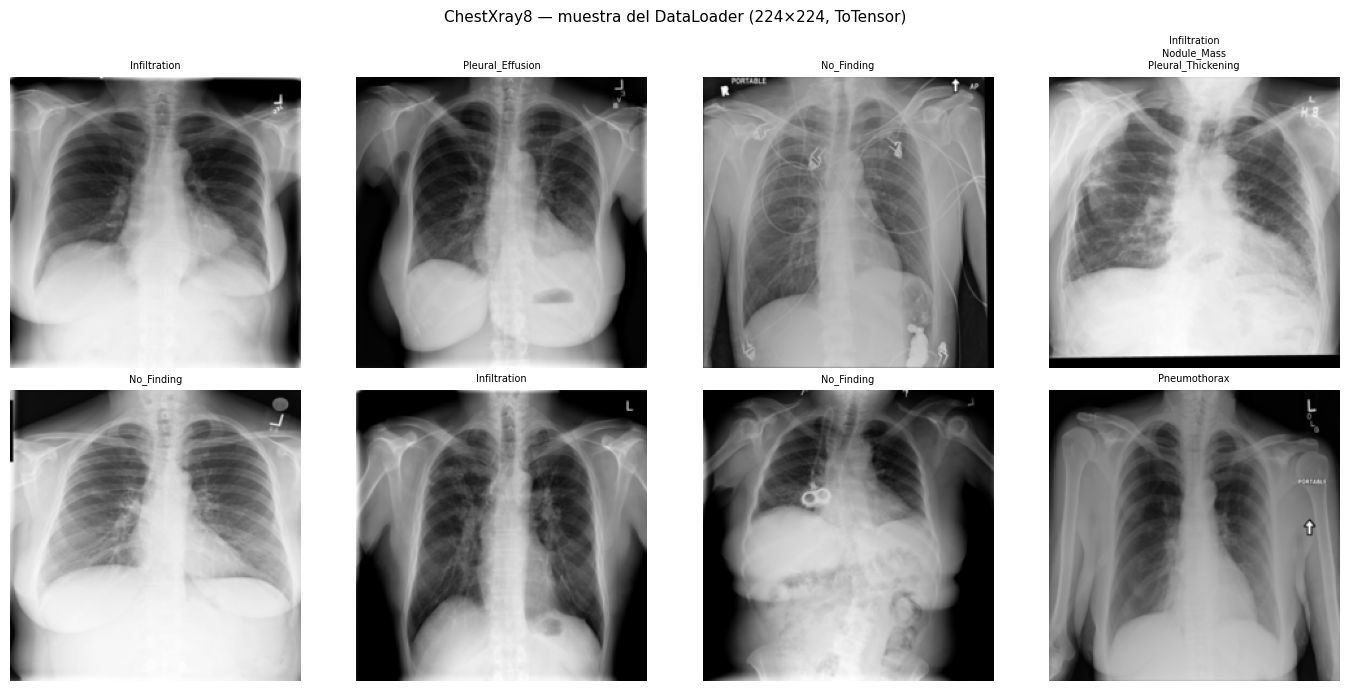

In [69]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("ChestXray8 — muestra del DataLoader (224×224, ToTensor)", fontsize=11)
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i].permute(1, 2, 0).mean(dim=2), cmap="gray")
    active = [CANONICAL_LABELS[j] for j, v in enumerate(lbls[i]) if v == 1.0]
    ax.set_title("\n".join(active) if active else "No Finding", fontsize=7)
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## 2. CheXpert (Stanford)

### 2.1 Estructura del dataset

```
chexpert/
├── train.csv    ← 223 414 imágenes con 14 labels
├── valid.csv    ← 234 imágenes (validation set pequeño)
└── train/
    └── patient00001_study1_view1_frontal.jpg   ← rutas aplanadas
        (originalmente: patient/study/view, aplanadas en preprocesado)
```

### 2.2 Formato de labels

CheXpert usa **cuatro valores distintos** por columna:
| Valor | Significado |
|---|---|
| `0.0` | Negativo (hallazgo ausente) |
| `1.0` | Positivo (hallazgo presente) |
| `-1.0` | **Incierto** (uncertainty label) |
| `NaN` | No mencionado en el reporte |

Las columnas son 14: `No Finding`, `Enlarged Cardiomediastinum`, `Cardiomegaly`, `Lung Opacity`, `Lung Lesion`, `Edema`, `Consolidation`, `Pneumonia`, `Atelectasis`, `Pneumothorax`, `Pleural Effusion`, `Pleural Other`, `Fracture`, `Support Devices`.

In [70]:
chex_csv = pd.read_csv(os.path.join(DATASET_ROOT, "chexpert", "train.csv"))
print(f"Filas: {len(chex_csv):,}  |  Columnas: {chex_csv.columns.tolist()}")
print()
label_cols = ["No Finding", "Cardiomegaly", "Edema", "Atelectasis", "Pleural Effusion"]
print(chex_csv[["Path"] + label_cols].head(8).to_string(index=False))
print()
print("Distribución de valores en 'Atelectasis':")
print(chex_csv["Atelectasis"].value_counts(dropna=False).to_string())
print()
print(f"Filas con al menos un -1 (inciertas): {(chex_csv[label_cols] == -1).any(axis=1).sum():,}")

Filas: 223,414  |  Columnas: ['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA', 'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices']

                                                           Path  No Finding  Cardiomegaly  Edema  Atelectasis  Pleural Effusion
CheXpert-v1.0-small/train/patient00001/study1/view1_frontal.jpg         1.0           NaN    NaN          NaN               NaN
CheXpert-v1.0-small/train/patient00002/study2/view1_frontal.jpg         NaN          -1.0   -1.0         -1.0              -1.0
CheXpert-v1.0-small/train/patient00002/study1/view1_frontal.jpg         NaN           NaN    NaN          NaN               NaN
CheXpert-v1.0-small/train/patient00002/study1/view2_lateral.jpg         NaN           NaN    NaN          NaN               NaN
CheXpert-v1.0-small/train/patient00003/study1/view

### 2.3 Mapeo a labels canónicos

| CheXpert raw | → | Canónico |
|---|---|---|
| No Finding | → | No_Finding |
| Cardiomegaly | → | Cardiomegaly |
| Edema | → | Edema |
| Consolidation | → | Consolidation |
| Pneumonia | → | Pneumonia |
| Atelectasis | → | Atelectasis |
| Pneumothorax | → | Pneumothorax |
| Pleural Effusion | → | Pleural_Effusion |
| Enlarged Cardiomediastinum, Lung Opacity, … | → | *(no mapeados)* |

**Labels ausentes en CheXpert** (NaN estructural):
- `Infiltration` — no está en el esquema de anotación de CheXpert
- `Nodule_Mass` — no está en CheXpert (tiene "Lung Lesion" pero semántica diferente)
- `Pleural_Thickening` — no está en CheXpert

**Tratamiento de `-1` (incertidumbre):** se convierte a `NaN` y se marca `uncertainty_mask=True`.

In [71]:
CHEXPERT_TO_CANONICAL = {
    "No Finding":       "No_Finding",
    "Cardiomegaly":     "Cardiomegaly",
    "Edema":            "Edema",
    "Consolidation":    "Consolidation",
    "Pneumonia":        "Pneumonia",
    "Atelectasis":      "Atelectasis",
    "Pneumothorax":     "Pneumothorax",
    "Pleural Effusion": "Pleural_Effusion",
}
# Ausentes en CheXpert → NaN estructural:
CHEXPERT_ABSENT = {"Infiltration", "Nodule_Mass", "Pleural_Thickening"}


def _chexpert_flat_path(path_str):
    """Convierte la ruta original de CheXpert a la ruta aplanada local.
    'CheXpert-v1.0-small/train/patientXXXX/studyY/viewZ.jpg'
    → 'chexpert/train/patientXXXX_studyY_viewZ.jpg'
    """
    sep = chr(92)  # backslash
    parts = path_str.replace(sep, "/").split("/")
    patient, study, fname = parts[-3], parts[-2], parts[-1]
    split_dir = parts[-4]  # 'train' o 'valid'
    return f"chexpert/{split_dir}/{patient}_{study}_{fname}"


class CheXpertDataset(Dataset):
    """CheXpert (Stanford). Mapea 8 labels canónicos; -1 → NaN (incierto)."""

    def __init__(self, root, transform=_BASE_TRANSFORM):
        self.root      = root
        self.transform = transform

        df = pd.read_csv(os.path.join(root, "chexpert", "train.csv"))

        src_cols = list(CHEXPERT_TO_CANONICAL.keys())
        self.uncertainty_mask = (df[src_cols] == -1).any(axis=1).values
        df[src_cols] = df[src_cols].replace(-1, float("nan"))

        self.image_paths = df["Path"].apply(_chexpert_flat_path).tolist()

        # Construir DataFrame de labels canónicos (NaN para ausentes)
        labels_df = pd.DataFrame(float("nan"), index=df.index, columns=CANONICAL_LABELS)
        for src_col, canonical in CHEXPERT_TO_CANONICAL.items():
            labels_df[canonical] = df[src_col].values

        self.labels_df = labels_df.reset_index(drop=True)
        n_u = self.uncertainty_mask.sum()
        print(f"CheXpertDataset: {len(self.image_paths):,} imágenes  |  "
              f"{n_u:,} con uncertainty_mask=True")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, self.image_paths[idx])
        img      = Image.open(img_path).convert("RGB")
        mask     = torch.tensor(self.labels_df.iloc[idx][CANONICAL_LABELS].notna().values.astype("float32"))
        labels   = torch.tensor(self.labels_df.iloc[idx][CANONICAL_LABELS].values.astype("float32"))
        if self.transform:
            img = self.transform(img)
        return img, labels, mask


chex_ds     = CheXpertDataset(DATASET_ROOT)
chex_loader = DataLoader(chex_ds, batch_size=8, shuffle=True, num_workers=0)

imgs, lbls, masks = next(iter(chex_loader))
print(f"Batch imágenes: {imgs.shape}  |  labels: {lbls.shape}")

CheXpertDataset: 223,414 imágenes  |  73,497 con uncertainty_mask=True
Batch imágenes: torch.Size([8, 3, 224, 224])  |  labels: torch.Size([8, 11])


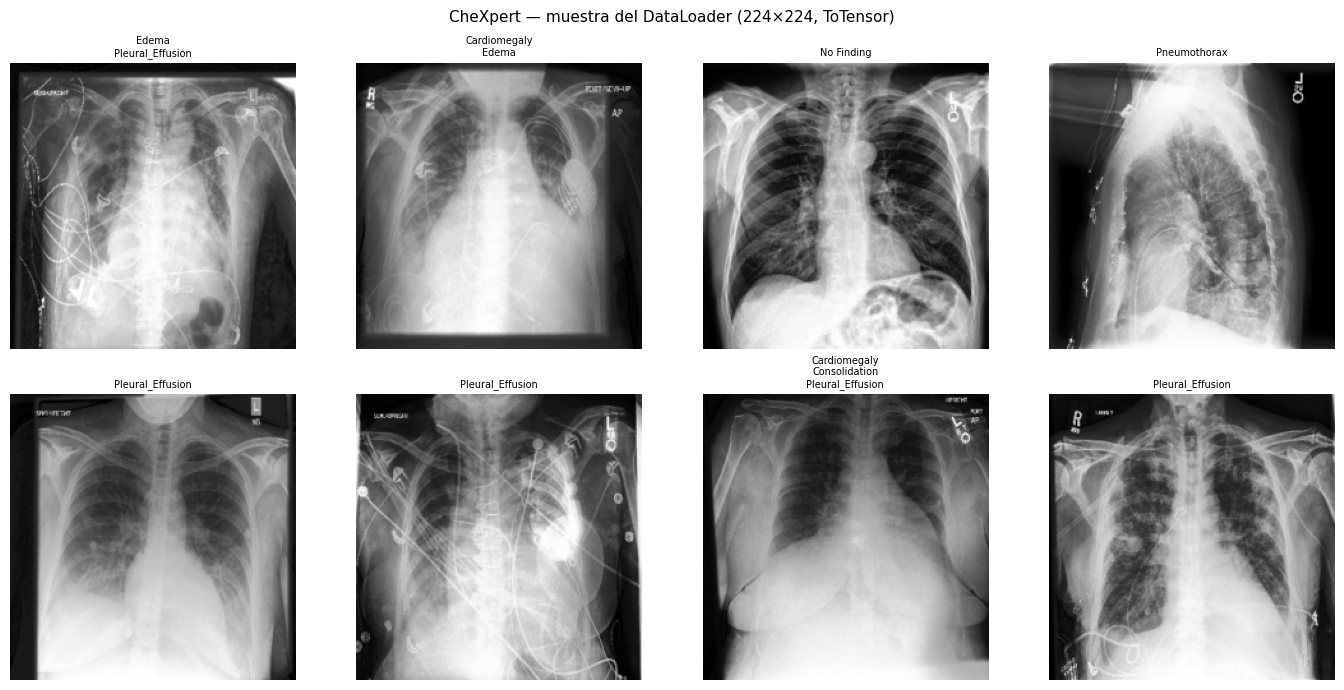

In [72]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("CheXpert — muestra del DataLoader (224×224, ToTensor)", fontsize=11)
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i].permute(1, 2, 0).mean(dim=2), cmap="gray")
    active = [CANONICAL_LABELS[j] for j, v in enumerate(lbls[i]) if v == 1.0]
    ax.set_title("\n".join(active) if active else "No Finding", fontsize=7)
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## 3. VinBigData (Kaggle)

### 3.1 Estructura del dataset

```
VinBigData/
├── train.csv   ← 67 914 filas (N_radiólogos × N_findings × N_imágenes)
└── train/
    └── {image_id}.jpg    ← 15 000 imágenes
```

### 3.2 Formato de labels

A diferencia de los otros datasets, **cada fila es un hallazgo anotado por un radiólogo**:

| image_id | class_name | class_id | rad_id | x_min | … |
|---|---|---|---|---|---|
| abc123 | Cardiomegaly | 3 | R1 | 100 | … |
| abc123 | No finding | 14 | R2 | | … |
| abc123 | Cardiomegaly | 3 | R3 | 105 | … |

Cada imagen tiene **múltiples radiólogos** que pueden votar el mismo o distintos hallazgos. El label final se determina por **mayoría**: si ≥ 50 % de los radiólogos de esa imagen votaron el hallazgo, se considera positivo.

In [73]:
vin_csv = pd.read_csv(os.path.join(DATASET_ROOT, "VinBigData", "train.csv"))
print(f"Filas: {len(vin_csv):,}  |  Columnas: {vin_csv.columns.tolist()}")
print(f"Imágenes únicas: {vin_csv['image_id'].nunique():,}")
print(f"Radiólogos únicos: {vin_csv['rad_id'].nunique()}")
print(f"Clases: {sorted(vin_csv['class_name'].unique())}")
print()
print("Primeras 12 filas (una fila por hallazgo por radiólogo):")
print(vin_csv[["image_id", "class_name", "rad_id"]].head(12).to_string(index=False))

Filas: 67,914  |  Columnas: ['Unnamed: 0', 'image_id', 'class_name', 'class_id', 'rad_id', 'x_min', 'y_min', 'x_max', 'y_max', 'raw_x_min', 'raw_x_max', 'raw_y_min', 'raw_y_max', 'raw_width', 'raw_height', 'scale_x', 'scale_y']
Imágenes únicas: 15,000
Radiólogos únicos: 17
Clases: ['Aortic enlargement', 'Atelectasis', 'Calcification', 'Cardiomegaly', 'Consolidation', 'ILD', 'Infiltration', 'Lung Opacity', 'No finding', 'Nodule/Mass', 'Other lesion', 'Pleural effusion', 'Pleural thickening', 'Pneumothorax', 'Pulmonary fibrosis']

Primeras 12 filas (una fila por hallazgo por radiólogo):
                        image_id         class_name rad_id
78aa8415fbf1c792f7d7c53349d44d4f         No finding    R16
78aa8415fbf1c792f7d7c53349d44d4f         No finding    R17
78aa8415fbf1c792f7d7c53349d44d4f         No finding    R11
183015e171f5159d7e60d43578632a3f Aortic enlargement     R8
183015e171f5159d7e60d43578632a3f Pleural thickening     R9
183015e171f5159d7e60d43578632a3f   Pleural effusion   

In [74]:
# Ejemplo de votación para una imagen específica
example_id = vin_csv["image_id"].iloc[0]
example    = vin_csv[vin_csv["image_id"] == example_id][["class_name", "rad_id"]]
n_rads     = example["rad_id"].nunique()
vote_count = example.groupby("class_name")["rad_id"].nunique().sort_values(ascending=False)

print(f"Imagen: {example_id}  |  {n_rads} radiólogos  |  umbral ≥ {n_rads * 0.5:.1f}")
print()
for cls, cnt in vote_count.items():
    status = "POSITIVO ✓" if cnt >= n_rads * 0.5 else "negativo"
    print(f"  {cls:<30} {cnt}/{n_rads}  {status}")

Imagen: 78aa8415fbf1c792f7d7c53349d44d4f  |  3 radiólogos  |  umbral ≥ 1.5

  No finding                     3/3  POSITIVO ✓


### 3.3 Mapeo a labels canónicos

| VinBigData raw | → | Canónico |
|---|---|---|
| No finding | → | No_Finding |
| Atelectasis | → | Atelectasis |
| Cardiomegaly | → | Cardiomegaly |
| Consolidation | → | Consolidation |
| Pleural effusion | → | Pleural_Effusion |
| Pleural thickening | → | Pleural_Thickening |
| Pneumothorax | → | Pneumothorax |
| Infiltration | → | Infiltration |
| Nodule/Mass | → | Nodule_Mass |
| Aortic enlargement, ILD, Lung Opacity, … | → | *(no mapeados)* |

**Labels ausentes en VinBigData** (NaN estructural):
- `Edema` — no está en el esquema de anotación de VinBigData
- `Pneumonia` — no está en VinBigData

In [75]:
VIN_TO_CANONICAL = {
    "No finding":         "No_Finding",
    "Atelectasis":        "Atelectasis",
    "Cardiomegaly":       "Cardiomegaly",
    "Consolidation":      "Consolidation",
    "Pleural effusion":   "Pleural_Effusion",
    "Pleural thickening": "Pleural_Thickening",
    "Pneumothorax":       "Pneumothorax",
    "Infiltration":       "Infiltration",
    "Nodule/Mass":        "Nodule_Mass",
}
VIN_ABSENT = {"Edema", "Pneumonia"}  # no observados → NaN estructural


class VinBigDataDataset(Dataset):
    """VinBigData (Kaggle). Agrega hallazgos por mayoría de radiólogos (≥ 50 %)."""

    def __init__(self, root, transform=_BASE_TRANSFORM):
        self.root      = root
        self.transform = transform

        df = pd.read_csv(os.path.join(root, "VinBigData", "train.csv"))

        df["canonical"] = df["class_name"].map(VIN_TO_CANONICAL)
        df_mapped = df.dropna(subset=["canonical"])

        # Contar radiólogos únicos que votaron cada (imagen, clase)
        votes = (
            df_mapped.groupby(["image_id", "canonical"])["rad_id"]
            .nunique().reset_index().rename(columns={"rad_id": "n_votes"})
        )
        n_rads = df.groupby("image_id")["rad_id"].nunique()
        votes["threshold"] = votes["image_id"].map(n_rads) * 0.5
        votes["positive"]  = (votes["n_votes"] >= votes["threshold"]).astype(float)

        # Pivotear a matriz imagen × clase
        all_images = df["image_id"].unique()
        label_matrix = (
            votes.pivot(index="image_id", columns="canonical", values="positive")
            .reindex(index=all_images, columns=CANONICAL_LABELS)
            .reset_index()
        )
        label_matrix.columns.name = None
        # Marcar ausentes como NaN estructural
        for col in VIN_ABSENT:
            label_matrix[col] = float("nan")

        self.df = label_matrix.reset_index(drop=True)
        print(f"VinBigDataDataset: {len(self.df):,} imágenes")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.root, "VinBigData", "train", f"{row['image_id']}.jpg")
        img      = Image.open(img_path).convert("RGB")
        mask     = torch.tensor(row[CANONICAL_LABELS].notna().values.astype("float32"))
        labels   = torch.tensor(row[CANONICAL_LABELS].values.astype("float32"))
        if self.transform:
            img = self.transform(img)
        return img, labels, mask


vin_ds     = VinBigDataDataset(DATASET_ROOT)
vin_loader = DataLoader(vin_ds, batch_size=8, shuffle=False, num_workers=0)

imgs, lbls, masks = next(iter(vin_loader))
print(f"Batch imágenes: {imgs.shape}  |  labels: {lbls.shape}")

VinBigDataDataset: 15,000 imágenes
Batch imágenes: torch.Size([8, 3, 224, 224])  |  labels: torch.Size([8, 11])


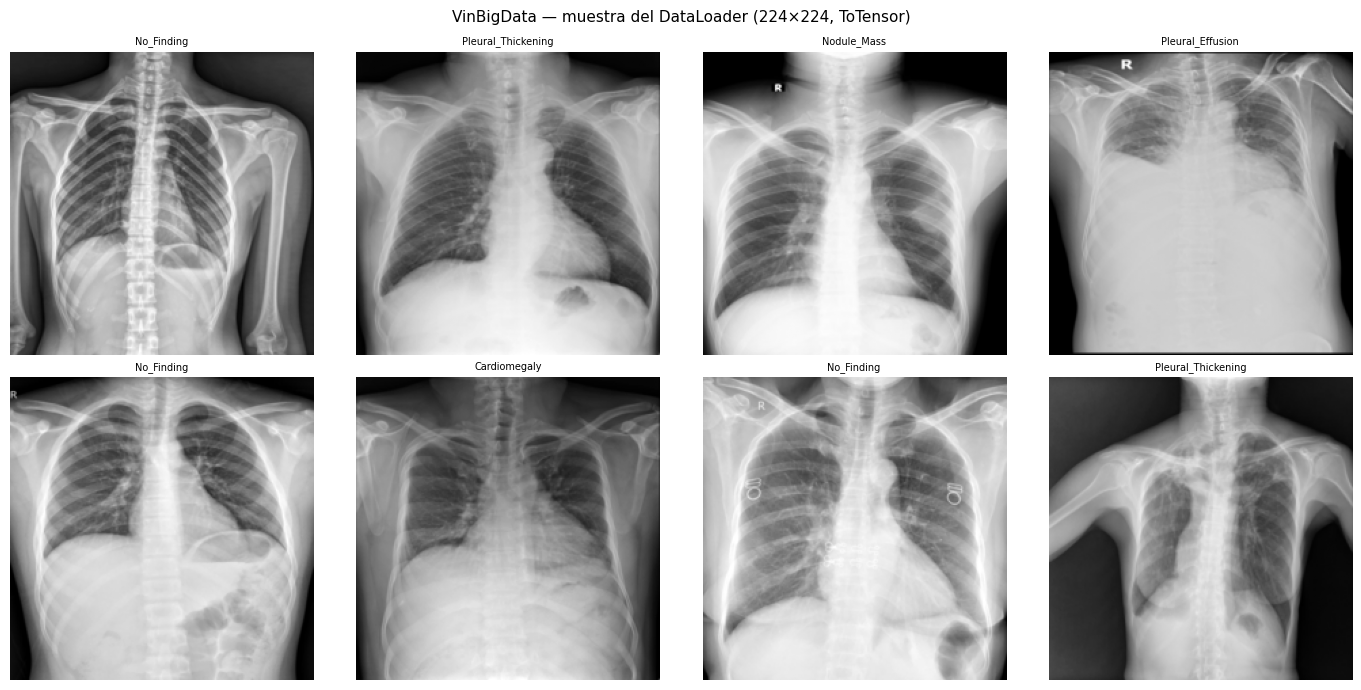

In [76]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("VinBigData — muestra del DataLoader (224×224, ToTensor)", fontsize=11)
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i].permute(1, 2, 0).mean(dim=2), cmap="gray")
    active = [CANONICAL_LABELS[j] for j, v in enumerate(lbls[i]) if v == 1.0]
    ax.set_title("\n".join(active) if active else "No Finding", fontsize=7)
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## 4. Estructura unificada

Los tres datasets producen la **misma estructura canónica**: 11 columnas de labels binarios (0.0 / 1.0 / NaN).
El NaN tiene dos causas distintas:
- **NaN de incertidumbre**: el radiólogo mencionó el hallazgo pero con duda (`-1` en CheXpert)
- **NaN estructural**: el dataset no anota esa clase (e.g., CheXpert no tiene `Infiltration`)

In [77]:
# Muestra de 1 fila por fuente con la misma estructura
cx8_sample  = cx8_ds.df.iloc[0]
chex_sample = chex_ds.labels_df.iloc[0]
vin_sample  = vin_ds.df.iloc[0]

comparison = pd.DataFrame({
    "Label":      CANONICAL_LABELS,
    "ChestXray8": cx8_sample[CANONICAL_LABELS].values,
    "CheXpert":   chex_sample[CANONICAL_LABELS].values,
    "VinBigData": vin_sample[CANONICAL_LABELS].values,
})
print("=== Estructura unificada — 1 fila de muestra por fuente ===")
print(comparison.to_string(index=False))

print()
print("=== Cobertura por fuente (NaN estructural = clase no anotada en ese dataset) ===")
coverage = pd.DataFrame({
    "Label":       CANONICAL_LABELS,
    "ChestXray8":  ["✓"] * 11,
    "CheXpert":    [
        "NaN" if l in {"Infiltration", "Nodule_Mass", "Pleural_Thickening"} else "✓"
        for l in CANONICAL_LABELS
    ],
    "VinBigData":  [
        "NaN" if l in {"Edema", "Pneumonia"} else "✓"
        for l in CANONICAL_LABELS
    ],
})
print(coverage.to_string(index=False))

=== Estructura unificada — 1 fila de muestra por fuente ===
             Label ChestXray8  CheXpert VinBigData
       Atelectasis        0.0       NaN        NaN
      Cardiomegaly        1.0       NaN        NaN
     Consolidation        0.0       NaN        NaN
             Edema        0.0       NaN        NaN
  Pleural_Effusion        0.0       NaN        NaN
         Pneumonia        0.0       NaN        NaN
      Pneumothorax        0.0       0.0        NaN
      Infiltration        0.0       NaN        NaN
       Nodule_Mass        0.0       NaN        NaN
Pleural_Thickening        0.0       NaN        NaN
        No_Finding        0.0       1.0        1.0

=== Cobertura por fuente (NaN estructural = clase no anotada en ese dataset) ===
             Label ChestXray8 CheXpert VinBigData
       Atelectasis          ✓        ✓          ✓
      Cardiomegaly          ✓        ✓          ✓
     Consolidation          ✓        ✓          ✓
             Edema          ✓        ✓        